In [19]:
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = '/gpfs/gibbs/pi/reilly/tabula_data'
PARAMS_PATH = '../model_fitting'

In [3]:
class DataSet(dict):
    def __init__(self, path):
        self.filepath = path
        self.parquet = pq.ParquetFile(self.filepath)
    
    def __getitem__(self, key):
        try:
            return self.parquet.read([key]).to_pandas()[key]
        except:
            raise KeyError

    def __reduce__(self):
        #return self.parquet.read().to_pandas().__reduce__()
        return (self.__class__, (self.filepath, ))

# Combo dataset, grouped by CRE/Cell Type

Convert to consistent formatting and naming 

Each entry is a CRE measured in a given cell type, collapsed over multiple barcodes

In [4]:
counts = pd.read_table('%s/shendure/GSE217686_assigned_oBC_CRE_mBC_joined_counts_sc_rep_mEB_series.txt' % DATA_PATH)
counts.columns = ['cell_bc', 'rep_id', 'transfection_bc', 'mpra_bc', 'cre_class', 'cre_id'
                    ,'reads_transfection_bc', 'umis_transfection_bc', 
                    'reads_mpra_bc', 'umis_mpra_bc']


In [5]:
cell_type_mapping = pd.read_table('%s/shendure/meb_cbc_to_cell_type_mapping.txt' % DATA_PATH)

In [6]:
cell_type_mapping

,orig.ident,nCount_RNA,nFeature_RNA,percent_mt,seurat_clusters,annotation
A1_AAACCCAAGATGGGCT-1,repA1,890,540,6.292135,1,Neuroectoderm (brain)
A1_AAACCCAAGGATTTGA-1,repA1,2311,1245,4.456945,4,Ex. Endoderm (parietal)
A1_AAACCCAGTGCCTAAT-1,repA1,4180,1766,2.607656,2,Mesoderm
A1_AAACCCAGTGTTAGCT-1,repA1,4597,2100,5.895149,1,Neuroectoderm (brain)
A1_AAACCCAGTTCCGCTT-1,repA1,3747,1893,5.310915,1,Neuroectoderm (brain)
...,...,...,...,...,...,...
2B2_TTTGTTGGTGCATTTG-1,rep2B2,4190,1822,2.840095,5,Epiblast/primitive streak
2B2_TTTGTTGGTTCGGTTA-1,rep2B2,746,543,7.640751,7,Neuroectoderm (rostral)
2B2_TTTGTTGTCAGGACAG-1,rep2B2,1961,1058,6.833248,3,Surface Ectoderm
2B2_TTTGTTGTCCCTCAAC-1,rep2B2,814,539,5.896806,3,Surface Ectoderm


In [7]:
cell_type_mapping.loc[counts['cell_bc']]

,orig.ident,nCount_RNA,nFeature_RNA,percent_mt,seurat_clusters,annotation
A1_GTTACCCAGTTGAAGT-1,repA1,3913,1664,4.702274,3,Surface Ectoderm
A1_GTTACCCAGTTGAAGT-1,repA1,3913,1664,4.702274,3,Surface Ectoderm
A1_GTTACCCAGTTGAAGT-1,repA1,3913,1664,4.702274,3,Surface Ectoderm
A1_GTTACCCAGTTGAAGT-1,repA1,3913,1664,4.702274,3,Surface Ectoderm
A1_GTTACCCAGTTGAAGT-1,repA1,3913,1664,4.702274,3,Surface Ectoderm
...,...,...,...,...,...,...
2B2_TTCTGTAAGGCTCTCG-1,rep2B2,522,384,5.747126,7,Neuroectoderm (rostral)
2B2_TTCTGTAAGGCTCTCG-1,rep2B2,522,384,5.747126,7,Neuroectoderm (rostral)
2B2_TGGAACTCAATCCTAG-1,rep2B2,968,619,1.136364,2,Mesoderm
2B2_TGGAACTCAATCCTAG-1,rep2B2,968,619,1.136364,2,Mesoderm


In [8]:
counts['cell_type'] = np.array(cell_type_mapping.loc[counts['cell_bc']]['annotation'])
counts['gex_umi'] = np.array(cell_type_mapping.loc[counts['cell_bc']]['nCount_RNA'])
# Compute mean GEx UMIs across all cells
mean_gex_umi = counts['gex_umi'].mean()

# Perform the normalization as described
counts['normalized_umis_mpra_bc'] = (
    counts['umis_mpra_bc'] / counts['gex_umi'] * mean_gex_umi
)

In [9]:
counts.to_csv('%s/shendure/shendure_counts_not_grouped.txt' % DATA_PATH, sep='\t', index=False)

In [10]:
counts_groupby_cre = counts.groupby(by=['cell_bc','rep_id','cre_class','cre_id','cell_type'], as_index=False).agg(lambda x: x.sum() if np.issubdtype(x.dtype, np.number) else ', '.join(x))
counts_groupby_cre = counts_groupby_cre.replace({'Epiblast/primitive streak' : 'EpiblastPrimitiveStreak', 
                            'Ex. Endoderm (parietal)' : 'ExEndodermParietal',
                            'Ex. Endoderm (visceral)': 'ExEndodermVisceral',
                            'Neuroectoderm (brain)' : 'NeuroectodermBrain',
                            'Neuroectoderm (rostral)' : 'NeuroectodermRostral',
                            'Surface Ectoderm' : 'SurfaceEctoderm'})
counts_groupby_cre 
counts_groupby_cre.to_csv('%s/shendure/shendure_counts_grouped.txt' % DATA_PATH, sep='\t', index=False)

In [11]:
counts_groupby_cre

,cell_bc,rep_id,cre_class,cre_id,cell_type,transfection_bc,mpra_bc,reads_transfection_bc,umis_transfection_bc,reads_mpra_bc,umis_mpra_bc,gex_umi,normalized_umis_mpra_bc
0,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Btg1_chr10_9572,NeuroectodermBrain,CATCGCTGAGTAAACG,GCGTACTCACCAGGT,73,67,0,0,2376,0.000000
1,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Gata4_chr14_5710,NeuroectodermBrain,GAGGATGAGTTGGAAT,CAATCGCACCCCCGA,167,159,0,0,2376,0.000000
2,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Klf4_chr4_3952,NeuroectodermBrain,CGTGAATTAATTCTAT,AACCCGGTAAATGTA,99,89,0,0,2376,0.000000
3,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Lama1_chr17_7793,NeuroectodermBrain,AGTAAGTCAGCTCTTT,CGTGACCTCTTCATT,159,147,0,0,2376,0.000000
4,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Sox17_chr1_67,NeuroectodermBrain,GACAATAAAATTCCAT,ACAGTCACAAATTTA,59,58,0,0,2376,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
778243,B2_TTTGTTGGTGGACCAA-1,B2,devCRE,Sparc_chr11_7207,ExEndodermVisceral,AATAATCACTCAAATT,TACCAACTGAGACAT,130,104,0,0,1438,0.000000
778244,B2_TTTGTTGGTGGACCAA-1,B2,devCRE,Tgfbi_chr13_5735,ExEndodermVisceral,AGTCCATGGAGGGAGG,GTTTACCACATTACT,108,98,0,0,1438,0.000000
778245,B2_TTTGTTGGTGGACCAA-1,B2,devCRE,Tgfbi_chr13_5741,ExEndodermVisceral,CTCAAGTTAGTAAGGG,CAGGGAACTGCCACC,75,68,19,1,1438,2.082943
778246,B2_TTTGTTGGTGGACCAA-1,B2,promoters,noP,ExEndodermVisceral,"ACTTCTCGCCAAGGAA, GTTTCTTCGTCTGCCC","TCCCGCTGACACTTA, ATGTGGGTCGTCTAT",200,166,0,0,2876,0.000000


In [15]:
table = pa.Table.from_pandas(counts)
pq.write_table(table, '%s/shendure/shendure_mpra_counts.parq' % DATA_PATH)
counts_parq = DataSet('%s/shendure/shendure_mpra_counts.parq' % DATA_PATH)


table = pa.Table.from_pandas(counts_groupby_cre)
pq.write_table(table, '%s/shendure/shendure_mpra_counts_grouped.parq' % DATA_PATH)
counts_parq_grouped = DataSet('%s/shendure/shendure_mpra_counts_grouped.parq' % DATA_PATH)

In [9]:
counts_groupby_cre

,cell_bc,rep_id,cre_class,cre_id,cell_type,transfection_bc,mpra_bc,reads_transfection_bc,umis_transfection_bc,reads_mpra_bc,umis_mpra_bc
0,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Btg1_chr10_9572,NeuroectodermBrain,CATCGCTGAGTAAACG,GCGTACTCACCAGGT,73,67,0,0
1,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Gata4_chr14_5710,NeuroectodermBrain,GAGGATGAGTTGGAAT,CAATCGCACCCCCGA,167,159,0,0
2,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Klf4_chr4_3952,NeuroectodermBrain,CGTGAATTAATTCTAT,AACCCGGTAAATGTA,99,89,0,0
3,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Lama1_chr17_7793,NeuroectodermBrain,AGTAAGTCAGCTCTTT,CGTGACCTCTTCATT,159,147,0,0
4,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Sox17_chr1_67,NeuroectodermBrain,GACAATAAAATTCCAT,ACAGTCACAAATTTA,59,58,0,0
...,...,...,...,...,...,...,...,...,...,...,...
778243,B2_TTTGTTGGTGGACCAA-1,B2,devCRE,Sparc_chr11_7207,ExEndodermVisceral,AATAATCACTCAAATT,TACCAACTGAGACAT,130,104,0,0
778244,B2_TTTGTTGGTGGACCAA-1,B2,devCRE,Tgfbi_chr13_5735,ExEndodermVisceral,AGTCCATGGAGGGAGG,GTTTACCACATTACT,108,98,0,0
778245,B2_TTTGTTGGTGGACCAA-1,B2,devCRE,Tgfbi_chr13_5741,ExEndodermVisceral,CTCAAGTTAGTAAGGG,CAGGGAACTGCCACC,75,68,19,1
778246,B2_TTTGTTGGTGGACCAA-1,B2,promoters,noP,ExEndodermVisceral,"ACTTCTCGCCAAGGAA, GTTTCTTCGTCTGCCC","TCCCGCTGACACTTA, ATGTGGGTCGTCTAT",200,166,0,0


In [10]:
count = 1
with open('%s/shendure_combo_model_params.txt' % PARAMS_PATH, 'w') as file:
    for model_type in ['poisson','zi_poisson','negative_binomial','zi_negative_binomial']:
        line = (str(count) + '\t' + model_type  + '\t' +  'umis_mpra_bc~C(cre_id)+C(cell_type)+0' + '\t' + 'rep_id' + '\t' + str(50000) + '\t' + 'COMBO'+ '\t' + 'ALL' + '\t' + 'shendure/shendure_mpra_counts_grouped.parq')
        file.write(line + "\n")
        print(line)
        count += 1

1	poisson	umis_mpra_bc~C(cre_id)+C(cell_type)+0	rep_id	50000	COMBO	ALL	shendure/shendure_mpra_counts_grouped.parq
2	zi_poisson	umis_mpra_bc~C(cre_id)+C(cell_type)+0	rep_id	50000	COMBO	ALL	shendure/shendure_mpra_counts_grouped.parq
3	negative_binomial	umis_mpra_bc~C(cre_id)+C(cell_type)+0	rep_id	50000	COMBO	ALL	shendure/shendure_mpra_counts_grouped.parq
4	zi_negative_binomial	umis_mpra_bc~C(cre_id)+C(cell_type)+0	rep_id	50000	COMBO	ALL	shendure/shendure_mpra_counts_grouped.parq


# Cell type individual groupings

In [11]:
counts_groupby_cell_agg = counts_groupby_cre.groupby(['cell_type']).agg(
    Sum=('umis_mpra_bc', 'sum'), Size=('umis_mpra_bc','size'), Mean=('umis_mpra_bc', 'mean')
)
counts_groupby_cell_agg

,Sum,Size,Mean
cell_type,,,
Cardiomyocytes,69992,12037,5.814738
EpiblastPrimitiveStreak,944637,66949,14.109800
ExEndodermParietal,232424,77898,2.983697
ExEndodermVisceral,353833,51713,6.842245
Haematoendothelial,169728,21749,7.803945
Mesoderm,452921,128596,3.522046
NeuroectodermBrain,665793,135976,4.896401
NeuroectodermRostral,52329,30630,1.708423
Pluripotent,1800660,165773,10.862203


In [12]:
cell_types = list(counts_groupby_cell_agg.index)
len(cell_types)

10

In [13]:
for i in cell_types:
    print(i)
    counts = counts_groupby_cre[counts_groupby_cre.cell_type == i]
    table = pa.Table.from_pandas(counts)
    pq.write_table(table, '%s/shendure/cell_type/shendure_mpra_counts_%s.parq' % (DATA_PATH, i))

Cardiomyocytes
EpiblastPrimitiveStreak
ExEndodermParietal
ExEndodermVisceral
Haematoendothelial
Mesoderm
NeuroectodermBrain
NeuroectodermRostral
Pluripotent
SurfaceEctoderm


In [14]:
count = 1
with open('%s/shendure_cell_type_individual_models_params.txt' % PARAMS_PATH, 'w') as file:
    for i in cell_types:
        for model_type in ['poisson','zi_poisson','negative_binomial','zi_negative_binomial']:
            line = (str(count) + '\t' + model_type  + '\t' +  'umis_mpra_bc~C(cre_id)+0' + '\t' + 'rep_id' + '\t' + str(50000) + '\t' + 'CELLTYPE'+ '\t' + i + '\t' + 'shendure/cell_type/shendure_mpra_counts_%s.parq' % i)
            file.write(line + "\n")
            print(line)
            count += 1

1	poisson	umis_mpra_bc~C(cre_id)+0	rep_id	50000	CELLTYPE	Cardiomyocytes	shendure/cell_type/shendure_mpra_counts_Cardiomyocytes.parq
2	zi_poisson	umis_mpra_bc~C(cre_id)+0	rep_id	50000	CELLTYPE	Cardiomyocytes	shendure/cell_type/shendure_mpra_counts_Cardiomyocytes.parq
3	negative_binomial	umis_mpra_bc~C(cre_id)+0	rep_id	50000	CELLTYPE	Cardiomyocytes	shendure/cell_type/shendure_mpra_counts_Cardiomyocytes.parq
4	zi_negative_binomial	umis_mpra_bc~C(cre_id)+0	rep_id	50000	CELLTYPE	Cardiomyocytes	shendure/cell_type/shendure_mpra_counts_Cardiomyocytes.parq
5	poisson	umis_mpra_bc~C(cre_id)+0	rep_id	50000	CELLTYPE	EpiblastPrimitiveStreak	shendure/cell_type/shendure_mpra_counts_EpiblastPrimitiveStreak.parq
6	zi_poisson	umis_mpra_bc~C(cre_id)+0	rep_id	50000	CELLTYPE	EpiblastPrimitiveStreak	shendure/cell_type/shendure_mpra_counts_EpiblastPrimitiveStreak.parq
7	negative_binomial	umis_mpra_bc~C(cre_id)+0	rep_id	50000	CELLTYPE	EpiblastPrimitiveStreak	shendure/cell_type/shendure_mpra_counts_EpiblastPrim

# CRE individual groupings

In [12]:
counts_groupby_cre_agg = counts_groupby_cre.groupby(['cre_id']).agg(
    Sum=('umis_mpra_bc', 'sum'), Size=('umis_mpra_bc','size'), Mean=('umis_mpra_bc', 'mean'), Mean_Norm=('normalized_umis_mpra_bc', 'mean')
)
counts_groupby_cre_agg

,Sum,Size,Mean,Mean_Norm
cre_id,,,,
Bend5_chr4_8168,66,2940,0.022449,0.028441
Bend5_chr4_8170,118,2196,0.053734,0.044221
Bend5_chr4_8172,36,2155,0.016705,0.018178
Bend5_chr4_8174,705,5884,0.119816,0.175163
Bend5_chr4_8175,3959,4437,0.892270,1.339279
...,...,...,...,...
minP,1167,15902,0.073387,0.066769
minP_w_20bp_buffer,2,161,0.012422,0.018493
noP,1821,19115,0.095265,0.088449


Pearson r = 1.000 (p = 0.00e+00)
Spearman ρ = 0.989 (p = 7.63e-176)


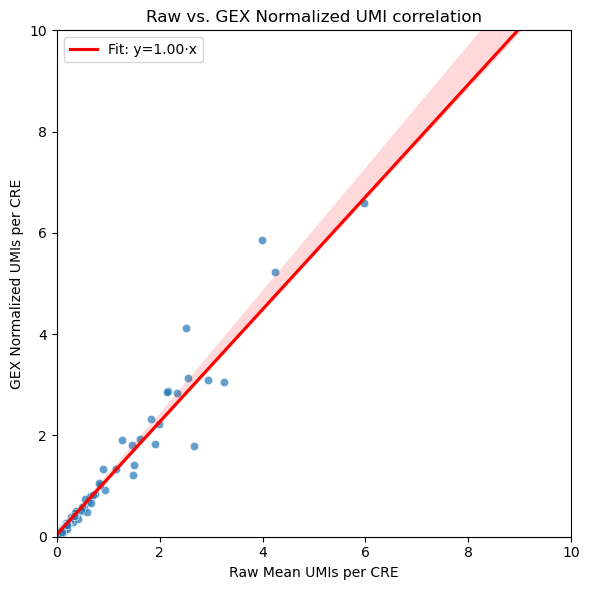

In [22]:
pearson_r, pearson_p = stats.pearsonr(counts_groupby_cre_agg['Mean'], counts_groupby_cre_agg['Mean_Norm'])
spearman_r, spearman_p = stats.spearmanr(counts_groupby_cre_agg['Mean'], counts_groupby_cre_agg['Mean_Norm'])

print(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")
print(f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})")


# 2) Scatter + regression line
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=counts_groupby_cre_agg,
    x='Mean',
    y='Mean_Norm',
    alpha=0.7
)
# add a linear fit
sns.regplot(
    data=counts_groupby_cre_agg,
    x='Mean',
    y='Mean_Norm',
    scatter=False,
    color='red',
    label=f'Fit: y={pearson_r:.2f}·x'
)

# (optional) log–log if needed:
# plt.xscale('log')
# plt.yscale('log')

plt.xlim(0,10)
plt.ylim(0,10)

plt.xlabel('Raw Mean UMIs per CRE')
plt.ylabel('GEX Normalized UMIs per CRE')
plt.title('Raw vs. GEX Normalized UMI correlation')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
cres = list(counts_groupby_cre_agg.index)
len(cres)

212

In [17]:
for i in cres:
    print(i)
    counts = counts_groupby_cre[counts_groupby_cre.cre_id == i]
    table = pa.Table.from_pandas(counts)
    pq.write_table(table, '%s/shendure/cre/shendure_mpra_counts_%s.parq' % (DATA_PATH, i))

Bend5_chr4_8168
Bend5_chr4_8170
Bend5_chr4_8172
Bend5_chr4_8174
Bend5_chr4_8175
Bend5_chr4_8179
Bend5_chr4_8192
Bend5_chr4_8199
Bend5_chr4_8201
Btg1_chr10_9572
Btg1_chr10_9578
Btg1_chr10_9588
Btg1_chr10_9593
Btg1_chr10_9612
Btg1_chr10_9613
Cdk5r1_chr11_12559
Cdk5r1_chr11_12562
Cdk5r1_chr11_12574
Cdk5r1_chr11_12575
Cdk5r1_chr11_12582
Cdk5r1_chr11_12590
Cdk5r1_chr11_12595
Cited2_chr10_1239
Cited2_chr10_1246
Cited2_chr10_1248
Cited2_chr10_1253
Cited2_chr10_1254
Cited2_chr10_1267
Cited2_chr10_1270
Col1a1_chr11_15258
Col1a1_chr11_15259
Col1a1_chr11_15269
Col1a1_chr11_15270
Col1a1_chr11_15273
Col1a1_chr11_15275
Col1a1_chr11_15276
Col1a1_chr11_15301
Col1a1_chr11_15306
Col1a1_chr11_15307
Col1a1_chr11_15316
Col1a1_chr11_15322
Col1a2_chr6_65
Col1a2_chr6_72
Col1a2_chr6_73
Col1a2_chr6_77
Col1a2_chr6_88
Col1a2_chr6_93
Col5a1_chr2_2558
Col5a1_chr2_2562
Col5a1_chr2_2565
Col5a1_chr2_2571
Col5a1_chr2_2575
Col5a1_chr2_2576
Col5a1_chr2_2586
Epas1_chr17_10056
Epas1_chr17_10057
Epas1_chr17_10061
Epas1_chr1

In [18]:
count = 1
with open('%s/shendure_cre_individual_models_params.txt' % PARAMS_PATH, 'w') as file:
    for i in cres:
        for model_type in ['poisson','zi_poisson','negative_binomial','zi_negative_binomial']:
            line = (str(count) + '\t' + model_type  + '\t' +  'umis_mpra_bc~C(cell_type)+0' + '\t' + 'rep_id' + '\t' + str(50000) + '\t' + 'CRE' + '\t' + i + '\t' + 'shendure/cre/shendure_mpra_counts_%s.parq' % i)
            file.write(line + "\n")
            print(line)
            count += 1

1	poisson	umis_mpra_bc~C(cell_type)+0	rep_id	50000	CRE	Bend5_chr4_8168	shendure/cre/shendure_mpra_counts_Bend5_chr4_8168.parq
2	zi_poisson	umis_mpra_bc~C(cell_type)+0	rep_id	50000	CRE	Bend5_chr4_8168	shendure/cre/shendure_mpra_counts_Bend5_chr4_8168.parq
3	negative_binomial	umis_mpra_bc~C(cell_type)+0	rep_id	50000	CRE	Bend5_chr4_8168	shendure/cre/shendure_mpra_counts_Bend5_chr4_8168.parq
4	zi_negative_binomial	umis_mpra_bc~C(cell_type)+0	rep_id	50000	CRE	Bend5_chr4_8168	shendure/cre/shendure_mpra_counts_Bend5_chr4_8168.parq
5	poisson	umis_mpra_bc~C(cell_type)+0	rep_id	50000	CRE	Bend5_chr4_8170	shendure/cre/shendure_mpra_counts_Bend5_chr4_8170.parq
6	zi_poisson	umis_mpra_bc~C(cell_type)+0	rep_id	50000	CRE	Bend5_chr4_8170	shendure/cre/shendure_mpra_counts_Bend5_chr4_8170.parq
7	negative_binomial	umis_mpra_bc~C(cell_type)+0	rep_id	50000	CRE	Bend5_chr4_8170	shendure/cre/shendure_mpra_counts_Bend5_chr4_8170.parq
8	zi_negative_binomial	umis_mpra_bc~C(cell_type)+0	rep_id	50000	CRE	Bend5_chr4_

In [19]:
PARAMS_PATH

'../model_fitting'